# Using the QM9 Dataset

## About the dataset: 
Molecules consist of H,C,O,N and F atoms, and contain up to 9 heavy atoms. 


In [1]:
import torch
from torch_geometric.transforms import BaseTransform, Compose
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv

import numpy as np

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# using this to set the y value we want as our target

class SetTarget(BaseTransform):
    '''
    Transform to modify target vector so there is a single value.
    
    Choose from 0-18 for target values described here: 
    https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html#torch_geometric.datasets.QM9
    '''
    def __init__(self,target):
        self.target = target
        
    def __call__(self,data):
        data.y = data.y[:,self.target]
        return data
        

In [3]:
# We are going to use the first y value as our target, so we set that here:
assignTarget = SetTarget(0)

# this will create a folder called data in the same directory as this notebook
qm9 = QM9(root='data', transform = assignTarget)

#let's take a quick peek at the first data object
qm9[0]

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])

### The data object 

This is how it stores a molecule and the target attribute(s):

__x__: node (atom) features 
- positions 0-4: one hot encoding of H,C,N,O,F
- 5: atomic number
- 6: aromatic (boolean)
- 7: SP hybridization (boolean)
- 8: SP2 hybridization (boolean)
- 9: SP3 hybridization (boolean)
- 10: number of attached hydrogens

__edge_index__: adjacency matrix (bonds between atoms)
<br>
__edge_attr__: edge features (positions 0-3: one hot encoding of bond types: single, double, triple, aromatic)
<br>
__pos__: 3D atom coordinates
<br>
__z__: atomic numbers
<br>
__smiles__: the molecule's SMILES string
<br>
__y__: target values (There are 19 regression target values included in this dataset, described here: https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.datasets.QM9.html#torch_geometric.datasets.QM9)

### Possible target values

#### Scatterplot of all targets

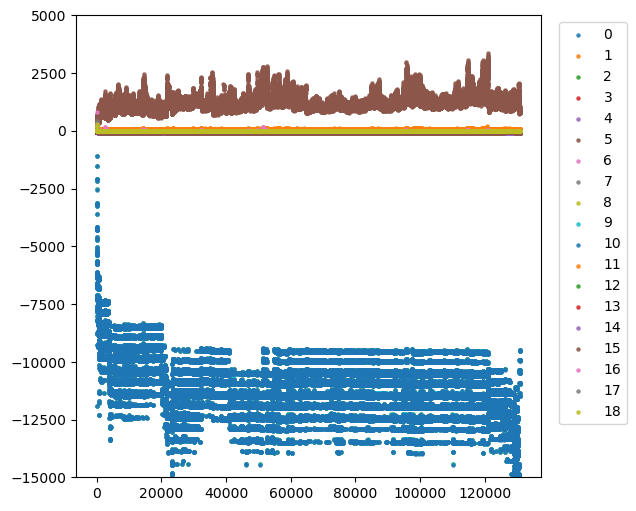

In [4]:
from matplotlib import pyplot as plt


idx = np.arange(len(qm9))
plt.figure(figsize=(6, 6))

for i in range(19):
    qm9.transform = SetTarget(i)
    all_y = torch.cat([data.y for data in qm9], dim=0)  
    plt.scatter(idx, all_y.cpu().numpy(), label=i, alpha=0.8, s=5)
bottom, top = plt.ylim() 
plt.ylim(-15000,5000)
plt.legend(loc="upper right", bbox_to_anchor=(1.2,1))
plt.show()

#### Violin plots

Let's try a different kind of plot since the scatterplot wasn't great with everything together. (We could also create separate scatterplots.)

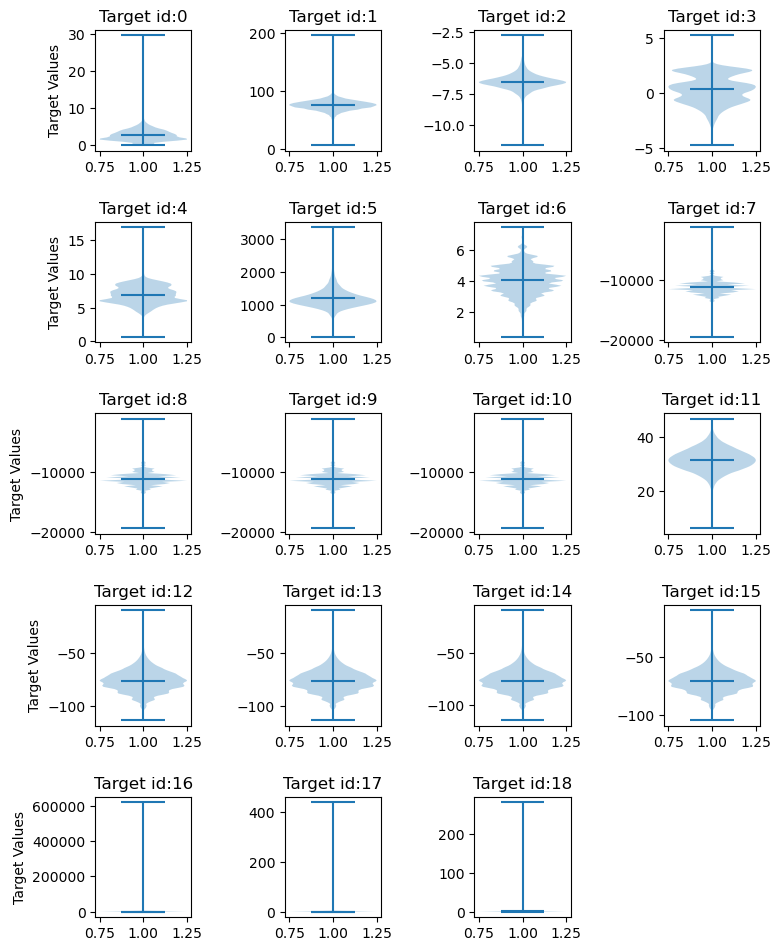

In [7]:
array_shape = (5,4)

fig, axs = plt.subplots(5,4)
# Set overall figure size (width, height) in inches
fig.set_size_inches(8, 10)
plt.tight_layout(pad=3.0) 

for i in range(19):
    row, col = np.unravel_index(i, array_shape)
    qm9.transform = SetTarget(i)
    all_y = torch.cat([data.y for data in qm9], dim=0)  
    y_val = all_y.cpu().numpy()
    
    axs[row,col].violinplot(y_val, positions=None, vert=True, widths=0.5, showmeans=True)
    axs[row,col].set_title('Target id:'+ str(i))    
axs[4,3].axis('off')
for ax in axs[:,0]:
    ax.set_ylabel('Target Values')
plt.show()

### We can look at each part of a data sample like this:

In [8]:
qm9[0], qm9[0].x, qm9[0].edge_attr, qm9[0].y

(Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1]),
 tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]]),
 tensor([[1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.]]),
 tensor([157.7070]))

### Changing the Target

Since we changed the target to make plots, we need to set it to the property we want to predict.

In [9]:
# Use a different target
print('current target value:', qm9[0].y)
target_index = 11
qm9.transform = SetTarget(target_index)
print('new target value:', qm9[0].y)


current target value: tensor([157.7070])
new target value: tensor([6.4690])


## Visualizing molecules

### Drawing a molecule

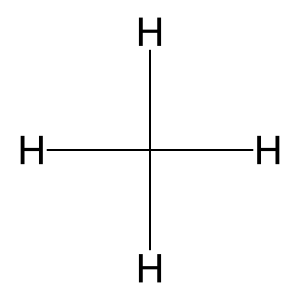

In [10]:
# we can use RDKit to visualize the molecules
from rdkit import Chem
from rdkit.Chem import Draw

img = Draw.MolToImage(Chem.AddHs(Chem.MolFromSmiles(qm9[0].smiles)))
img

### Visualizing the input features of a molecule

In [11]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


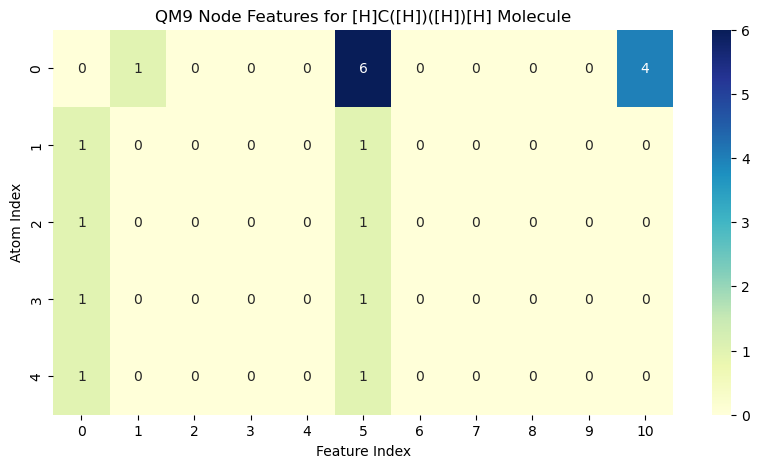

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

x = qm9[0].x.numpy()  # Shape: [num_atoms, num_features]

plt.figure(figsize=(10, 5))
sns.heatmap(x, annot=True, cbar=True, cmap='YlGnBu')
plt.xlabel("Feature Index")
plt.ylabel("Atom Index")
plt.title("QM9 Node Features for "+qm9[0].smiles+" Molecule")
plt.show()

The y axis contains the atoms in the molecule. There are 11 features for each atom. 
Features 0-4 are the one hot encoding of the atom. The dataset only contains atoms that have C,H,O,N or F atoms. 
Feature 5 is the atomic number.
Feature 6 is whether the atom is aromatic
Features 7,8,9 are the SP, SP2, SP3 hybridization.
Feature 10 is the number of attached hydrogens. 

## Creating train/val/test datasets

In [13]:
print('There are',len(qm9),'samples in this dataset.')

There are 130831 samples in this dataset.


In [14]:
# This dataset is a little bigger than we need for this demo, so let's just use a subset

#shuffle first so we get a nice variety
qm9 = qm9.shuffle()

# let's use 20k, and split to train/val/test 70/10/20
sample_count = 20000
train_end = int(sample_count * 0.7)
val_end = train_end + int(sample_count* 0.1)
test_end = val_end + int(sample_count * 0.2)


### Normalize the Target values 

In [15]:
# collect the target y values from the training to use for normalizing
train_y2 =torch.cat([qm9[i].y for i in range(train_end)], dim=0)

# compute mean and standard deviation
train_mean = train_y2.mean()
train_std = train_y2.std()

In [16]:

class NormalizeTarget(BaseTransform):
    '''
    Transform to normalize target vector.

    Parameters:
    ----------
    mean : mean of the training data target values 
    std : standard deviation of the training data target values
    
    '''
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std

    def __call__(self, data):
        data.y = (data.y - self.mean) / self.std
        return data

# we set the target_index earlier, but it's here as well just in case we changed it above and forgot
target_index = 11

# see what it is now
print("current value:", qm9[0].y.item())

# transform values
qm9.transform = Compose([SetTarget(target_index),NormalizeTarget(train_mean, train_std)])

# value after normalization
print("normalized value", qm9[0].y.item())

current value: 36.518001556396484
normalized value 1.1808315515518188


### Why are we setting the target again? We already set it! 

This is because Pytorch Geometric's transform is stateless and applied on access, so if you call it again, 
you are telling Pytorch you don't care what it did before and it just discards it and behaves as if the 
original transform that selected the target never happened.

If you want to see what happens, try replacing

with

The shape of qm\[0].y will change from \[1] to \[1,9] because the previous transform call to setTarget is forgotten. 
The mean and standard deviation values that we calculated for our specific target will be applied to all targets, which is also probably not ideal.

### Use the DataLoader to create training, validation and test loads

In [17]:
# use the DataLoader

# set the batch size
batch = 50
train_loader = DataLoader(qm9[:train_end], batch_size = batch, shuffle = True)
val_loader = DataLoader(qm9[train_end:val_end], batch_size = batch, shuffle = True)
test_loader = DataLoader(qm9[val_end:test_end], batch_size = batch, shuffle = False)


## Now the data is ready to use to train a model!